# **Загрузка данных и подготовка**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.optimizers import Adam

# Скачивание данных
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/traff.csv', 'traff.csv', quiet=True)

# Загрузка и первичный анализ
df = pd.read_csv('traff.csv', header=None, names=['date', 'value'], sep=',',thousands=',')
df = df.dropna() # Удаляет все строки с пропусками
df = df.reset_index(drop=True) # Сбрасывает индексы
# Если в файле даты, переводим их, но для обучения нам нужны только значения
data = df['value'].values.reshape(-1, 1)

# # Масштабирование (для трафика лучше всего подходит MinMaxScaler от 0 до 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Параметры задания
win_len = 5
batch_size = 32
df = df.dropna()
# Разделение на выборки (90% обучение, 10% тест)
train_len = int(len(data_scaled) * 0.9)

train_gen = TimeseriesGenerator(data_scaled, data_scaled, length=win_len, batch_size=batch_size, end_index=train_len)
test_gen = TimeseriesGenerator(data_scaled, data_scaled, length=win_len, batch_size=batch_size, start_index=train_len)


# **Построение нейронной сети**

In [32]:
model = Sequential([
    # Первый слой LSTM должен возвращать последовательность для следующего слоя
    LSTM(128, input_shape=(win_len, 1), return_sequences=True),
    Dropout(0.2),

    # Второй слой LSTM
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1) # Прогноз на 1 шаг
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

# Обучение
history = model.fit(train_gen, epochs=30, validation_data=test_gen, verbose=1)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0381 - val_loss: 0.0431
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - val_loss: 0.0175
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - val_loss: 0.0178
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0159
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0156
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0159
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 - val_loss: 0.0144
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0158
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0055 - val_loss: 0.0140
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0148
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0139
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.013

# **Сравнение графиков корреляции**

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


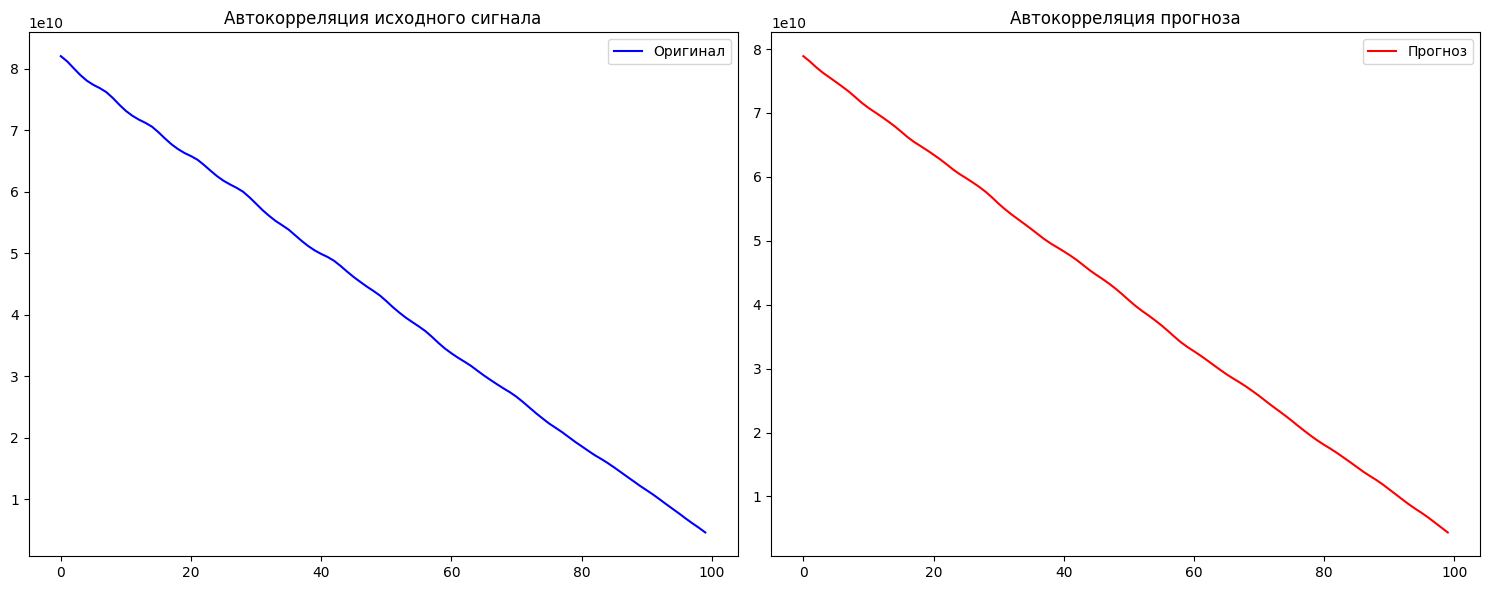

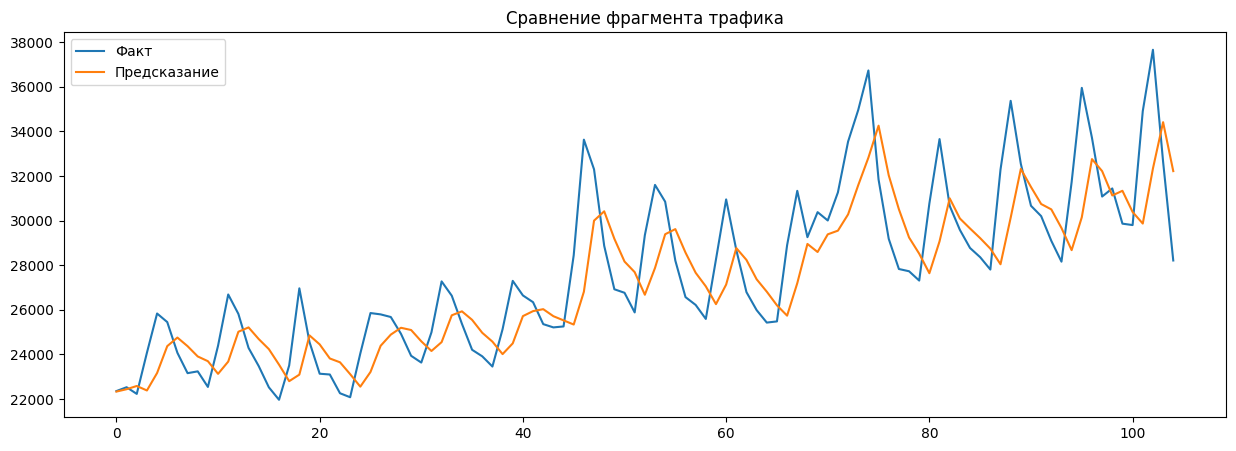

In [33]:
# Получение предсказаний
predictions = model.predict(test_gen)

# Обратное масштабирование для корректного сравнения
y_pred = scaler.inverse_transform(predictions)
y_true = data[train_len + win_len:]

# Функция для отрисовки автокорреляции
def plot_autocorr(signal, title):
    signal_flat = signal.flatten()
    result = np.correlate(signal_flat, signal_flat, mode='full')
    return result[result.size // 2:]

plt.figure(figsize=(15, 6))

# График 1: Исходный сигнал (фрагмент теста)
plt.subplot(1, 2, 1)
plt.plot(plot_autocorr(y_true, "Original")[:100], label='Оригинал', color='blue')
plt.title('Автокорреляция исходного сигнала')
plt.legend()

# График 2: Прогноз
plt.subplot(1, 2, 2)
plt.plot(plot_autocorr(y_pred, "Forecast")[:100], label='Прогноз', color='red')
plt.title('Автокорреляция прогноза')
plt.legend()

plt.tight_layout()
plt.show()

# Финальное сравнение графиков в динамике
plt.figure(figsize=(15, 5))
plt.plot(y_true[:200], label='Факт')
plt.plot(y_pred[:200], label='Предсказание')
plt.title('Сравнение фрагмента трафика')
plt.legend()
plt.show()

In [23]:
print("Есть ли пустые значения в данных:", np.isnan(data_scaled).any())

Есть ли пустые значения в данных: True
